# Laboratório 05 — Binarização Local por Média de Vizinhança

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [10]:
uploaded = files.upload()
nome_arquivo = list(uploaded.keys())[0]

img = cv2.imread(nome_arquivo, cv2.IMREAD_GRAYSCALE)

altura, largura = img.shape
print(f"Imagem carregada: {largura}x{altura} pixels")

Saving images.jpg to images (1).jpg
Imagem carregada: 626x417 pixels


In [11]:
def binarizacao_local_pixel(imagem):
    h, w = imagem.shape
    saida = np.zeros((h, w), dtype=np.uint8)

    for i in range(1, h - 1):
        for j in range(1, w - 1):
            soma = 0
            for di in (-1, 0, 1):
                for dj in (-1, 0, 1):
                    soma += int(imagem[i + di, j + dj])

            media = soma / 9.0

            if imagem[i, j] >= media:
                saida[i, j] = 255
            else:
                saida[i, j] = 0

    return saida

In [12]:
img_local = binarizacao_local_pixel(img)

In [13]:
_, img_global = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

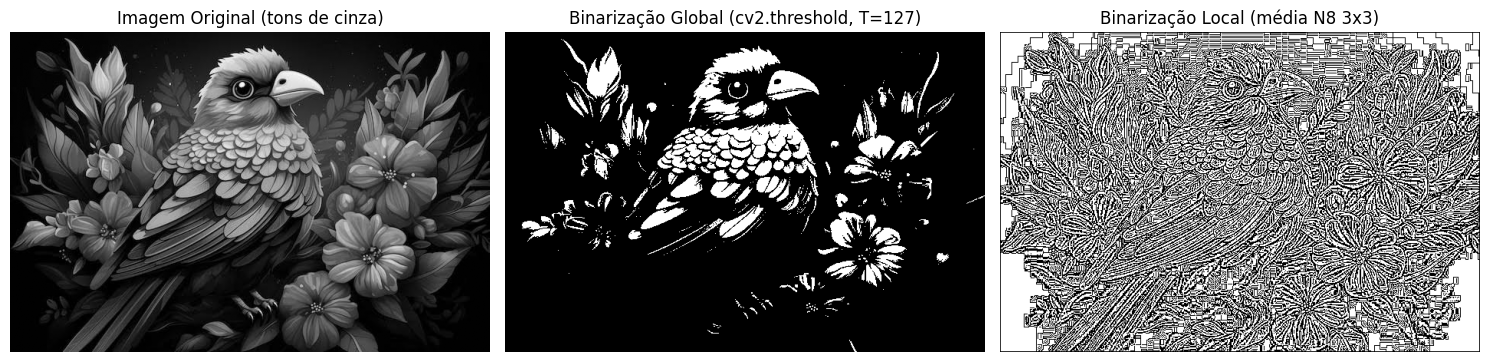

In [14]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Imagem Original (tons de cinza)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_global, cmap='gray')
plt.title('Binarização Global (cv2.threshold, T=127)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_local, cmap='gray')
plt.title('Binarização Local (média N8 3x3)')
plt.axis('off')

plt.tight_layout()
plt.show()